# Pipeline de Predição de Risco Escolar


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [ ]:
def limpar_colunas(df):
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()]
    return df

def padronizar(df, ano):
    df = limpar_colunas(df)

    col_inde = [
        c for c in df.columns
        if "INDE" in c and (str(ano)[-2:] in c or str(ano) in c)
    ]
    df["INDE"] = df[col_inde[0]] if col_inde else None

    mapa = {
        "Nome": "NOME",
        "Nome Anonimizado": "NOME",
        "Gênero": "SEXO",
        "Idade 22": "IDADE",
        "Idade": "IDADE",
        "Rec Psicologia": "REC_PSICO",
        "Rec Psicologia ": "REC_PSICO",
        "Rec Psicologia.": "REC_PSICO", 
        "IAN": "IAN",
        "IDA": "IDA",
        "IEG": "IEG",
        "IAA": "IAA",
        "IPS": "IPS",
        "IPP": "IPP",
        "IPV": "IPV",
        "Defas": "DEFASAGEM",
        "Defasagem": "DEFASAGEM",
        "Destaque IEG": "DESTAQUE_IEG",
        "Destaque IDA": "DESTAQUE_IDA",
    }

    df = df.rename(columns=mapa)

    COLS = [
        "RA", "NOME", "SEXO", "IDADE", "DEFASAGEM", "REC_PSICO",
        "IAN", "IDA", "IEG", "IAA",
        "IPS", "IPP", "IPV", "INDE",
        "DESTAQUE_IEG", "DESTAQUE_IDA"
    ]

    for col in COLS:
        if col not in df.columns:
            df[col] = None

    df = df[COLS].copy()
    df["ANO"] = ano
    return df

In [ ]:
arquivo = r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2022"), 2022)
df_2023 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2023"), 2023)
df_2024 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2024"), 2024)

df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)
df.head()

,RA,NOME,SEXO,IDADE,DEFASAGEM,REC_PSICO,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,DESTAQUE_IEG,DESTAQUE_IDA,ANO
0,RA-1,Aluno-1,Menina,19,-1,Requer avaliação,5.0,4.0,4.1,8.3,5.6,None,7.278,5.783,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
1,RA-2,Aluno-2,Menina,17,0,Sem limitações,10.0,6.8,5.2,8.8,6.3,None,6.778,7.055,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
2,RA-3,Aluno-3,Menina,17,0,Sem limitações,10.0,5.6,7.9,0.0,5.6,None,7.556,6.591,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
3,RA-4,Aluno-4,Menino,17,0,Requer avaliação,10.0,5.0,4.5,8.8,5.6,None,5.278,5.951,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
4,RA-5,Aluno-5,Menina,17,0,Requer avaliação,10.0,5.2,8.6,7.9,5.6,None,7.389,7.427,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022


In [ ]:
cols = ['IDADE','DEFASAGEM','IAN','IDA','IEG','IAA','IPS','IPP','IPV','INDE', 'ANO']

# verifica se as colunas possuem algum valor que não sejam números
for c in cols:
    erro = pd.to_numeric(df[c], errors='coerce').isna() & df[c].notna()
    print(c, "-> valores inválidos:", erro.sum(), "-> valor identificado: ", df.loc[erro, c].unique())

IDADE -> valores inválidos: 399 -> valor identificado:  [datetime.datetime(1900, 1, 8, 0, 0) datetime.datetime(1900, 1, 7, 0, 0)
 datetime.datetime(1900, 1, 11, 0, 0) datetime.datetime(1900, 1, 9, 0, 0)
 datetime.datetime(1900, 1, 10, 0, 0) datetime.datetime(1900, 1, 14, 0, 0)
 datetime.datetime(1900, 1, 13, 0, 0) datetime.datetime(1900, 1, 12, 0, 0)
 datetime.datetime(1900, 1, 15, 0, 0) datetime.datetime(1900, 1, 17, 0, 0)
 datetime.datetime(1900, 1, 16, 0, 0) datetime.datetime(1900, 1, 19, 0, 0)
 datetime.datetime(1900, 1, 18, 0, 0) datetime.datetime(1900, 1, 20, 0, 0)
 datetime.datetime(1900, 1, 21, 0, 0) datetime.datetime(1900, 1, 26, 0, 0)]
DEFASAGEM -> valores inválidos: 0 -> valor identificado:  []
IAN -> valores inválidos: 0 -> valor identificado:  []
IDA -> valores inválidos: 0 -> valor identificado:  []
IEG -> valores inválidos: 0 -> valor identificado:  []
IAA -> valores inválidos: 0 -> valor identificado:  []
IPS -> valores inválidos: 0 -> valor identificado:  []
IPP -> val

In [ ]:
# Converte para NaN os valores incorretos da coluna INDE
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')
# Converte para NaN os valores incorretos da coluna IDADE
df['IDADE'] = pd.to_numeric(df['IDADE'], errors='coerce')

In [ ]:
df["SEXO"].unique()

array(['Menina', 'Menino', 'Feminino', 'Masculino'], dtype=object)

In [ ]:
#padroniza a coluna sexo
mapa_sexo = {
    "Menina": "F",
    "Feminino": "F",
    "Menino": "M",
    "Masculino": "M"
}

df["SEXO"] = df["SEXO"].map(mapa_sexo)

In [ ]:
df["SEXO"].value_counts()

SEXO
F    1626
M    1404
Name: count, dtype: int64

In [ ]:
#converte para números para usar a coluna sexo como feature no modelo
df["SEXO"] = df["SEXO"].map({"F": 0, "M": 1})

# ✅ Features do texto (simples e fortes)
texto_cols = ["DESTAQUE_IEG", "DESTAQUE_IDA"]

# flag: existe observação?
df["tem_alerta_IEG"] = df["DESTAQUE_IEG"].notna().astype(int)
df["tem_alerta_IDA"] = df["DESTAQUE_IDA"].notna().astype(int)

# flag: contém "melhor" (ajuste palavras se quiser)
df["melhorar_IEG"] = df["DESTAQUE_IEG"].astype(str).str.contains("melhor", case=False, na=False).astype(int)
df["melhorar_IDA"] = df["DESTAQUE_IDA"].astype(str).str.contains("melhor", case=False, na=False).astype(int)

palavras_risco = [
    "melhor", "aten", "dific", "baixo",
    "insuf", "refor", "falta", "ausen", "pend"
]

df["alerta_texto"] = (
    df["DESTAQUE_IEG"].astype(str).str.lower().apply(
        lambda x: any(p in x for p in palavras_risco)
    )
).astype(int)


cols_num = ["IDADE","DEFASAGEM","IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]

df[cols_num] = df[cols_num].apply(pd.to_numeric, errors="coerce")
df[cols_num] = df[cols_num].fillna(df[cols_num].median(numeric_only=True))

df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")

In [ ]:
df = df.sort_values(["RA", "ANO"])

df["delta_IDA"] = df.groupby("RA")["IDA"].diff()
df["delta_INDE"] = df.groupby("RA")["INDE"].diff()

df["trend_IDA"] = (
    df.groupby("RA")["delta_IDA"]
      .transform(lambda x: x.rolling(2).mean())
)

df["trend_INDE"] = (
    df.groupby("RA")["delta_INDE"]
      .transform(lambda x: x.rolling(2).mean())
)

df["media_IDA"] = (
    df.groupby("RA")["IDA"]
      .transform(lambda x: x.expanding().mean())
)

df["media_INDE"] = (
    df.groupby("RA")["INDE"]
      .transform(lambda x: x.expanding().mean())
)

In [ ]:
# novas features fortes
df["quedas_consecutivas"] = (
    df.groupby("RA")["delta_INDE"]
      .transform(lambda x: (x < 0).rolling(2).sum())
)

df["volatilidade"] = df.groupby("RA")["INDE"].transform("std")

df["risco"] = (df["delta_INDE"] < -1).astype(int)

df_shift = df.sort_values(["RA", "ANO"]).copy()
df_shift["risco_futuro"] = df_shift.groupby("RA")["risco"].shift(-1)

df_model = df_shift.dropna(subset=["risco_futuro"]).copy()
df_model["risco_futuro"] = df_model["risco_futuro"].astype(int)

# ✅ Features de Psicologia (2022 tem, outros anos podem não ter)
df_model["REC_PSICO"] = df_model["REC_PSICO"].fillna("Não avaliado").astype(str).str.strip()

mapa_psico_nivel = {
    "Sem limitações": 0,
    "Não indicado": 0,
    "Não avaliado": 0,
    "Requer avaliação": 1,
    "Não atendido": 2,
}

df_model["psico_nivel"] = df_model["REC_PSICO"].map(mapa_psico_nivel).fillna(0).astype(int)

# flags opcionais (bem úteis)
df_model["psico_requer_avaliacao"] = (df_model["REC_PSICO"] == "Requer avaliação").astype(int)
df_model["psico_nao_atendido"] = (df_model["REC_PSICO"] == "Não atendido").astype(int)

In [ ]:
features = [
    "SEXO", "IDADE", "DEFASAGEM",
    "IAN", "IDA", "IEG", "IAA",
    "IPS", "IPP", "IPV",
    "delta_IDA", "trend_IDA", "media_IDA",
    "quedas_consecutivas", "volatilidade",
    "tem_alerta_IEG", "tem_alerta_IDA",
    "melhorar_IEG", "melhorar_IDA",
    "alerta_texto",
    "psico_nivel", "psico_requer_avaliacao", "psico_nao_atendido",
]

train_anos = [2022]
test_ano = 2023

# garante que todas existem
for f in features:
    if f not in df_model.columns:
        df_model[f] = 0

# garante numérico
df_model[features] = df_model[features].apply(pd.to_numeric, errors="coerce")

X_train = df_model[df_model["ANO"].isin(train_anos)][features].fillna(-1)
y_train = df_model[df_model["ANO"].isin(train_anos)]["risco_futuro"]

X_test  = df_model[df_model["ANO"] == test_ano][features].fillna(-1)
y_test  = df_model[df_model["ANO"] == test_ano]["risco_futuro"]


In [ ]:
def avaliar_modelo(model, X_train, y_train, X_test, y_test, limiar=0.25):
    model.fit(X_train, y_train)

    if len(getattr(model, "classes_", [])) < 2:
        print("⚠️ Treino ficou com 1 classe só:", model.classes_)
        print("Distribuição y_train:\n", y_train.value_counts())
        return None

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > limiar).astype(int)

    print("=== Classification Report ===")
    print(classification_report(y_test, y_pred))
    print("\nROC AUC:", roc_auc_score(y_test, y_prob))
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    return y_prob



In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

y_prob_rf = avaliar_modelo(rf, X_train, y_train, X_test, y_test, limiar=0.25)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       676
           1       0.42      0.74      0.54        89

    accuracy                           0.85       765
   macro avg       0.69      0.80      0.72       765
weighted avg       0.90      0.85      0.87       765


ROC AUC: 0.9170018615783525

Matriz de confusão:
[[585  91]
 [ 23  66]]


In [ ]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

y_prob_xgb = avaliar_modelo(xgb, X_train, y_train, X_test, y_test, limiar=0.25)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       676
           1       0.42      0.66      0.51        89

    accuracy                           0.85       765
   macro avg       0.68      0.77      0.71       765
weighted avg       0.89      0.85      0.87       765


ROC AUC: 0.900488664317532

Matriz de confusão:
[[593  83]
 [ 30  59]]


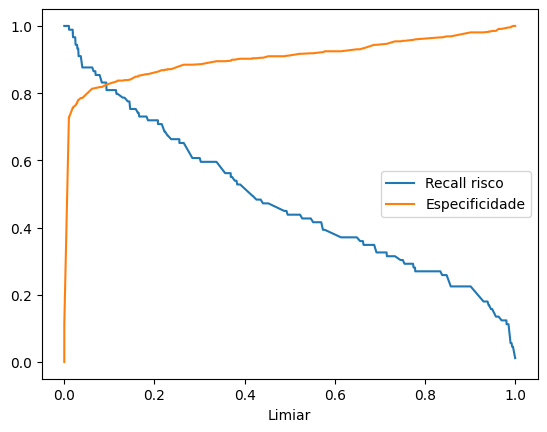

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.plot(thresholds, tpr, label="Recall risco")
plt.plot(thresholds, 1-fpr, label="Especificidade")
plt.xlabel("Limiar")
plt.legend()
plt.show()

In [ ]:
df_test = df_model[df_model["ANO"] == test_ano].copy()

X_test_alinhado = df_test[features].fillna(0)

df_test["prob"] = xgb.predict_proba(X_test_alinhado)[:, 1]

top = df_test.sort_values("prob", ascending=False).head(30)

print("Quantos riscos reais no TOP 30?")
print(top["risco_futuro"].sum())

Quantos riscos reais no TOP 30?
17


In [ ]:
if y_prob_xgb is not None:
    df_test = df_model[df_model["ANO"] == test_ano].copy()
    X_test_alinhado = df_test[features].fillna(0)

    df_test["prob"] = xgb.predict_proba(X_test_alinhado)[:, 1]

    top30 = df_test.sort_values("prob", ascending=False).head(30)
    print("Quantos riscos reais no TOP 30?", int(top30["risco_futuro"].sum()))

    for k in [10, 20, 30, 50, 100]:
        topk = df_test.sort_values("prob", ascending=False).head(k)
        acertos = int(topk["risco_futuro"].sum())
        print(f"Top {k}: {acertos} acertos → {(acertos/k):.2%}")

Quantos riscos reais no TOP 30? 17
Top 10: 7 acertos → 70.00%
Top 20: 12 acertos → 60.00%
Top 30: 17 acertos → 56.67%
Top 50: 24 acertos → 48.00%
Top 100: 40 acertos → 40.00%


In [ ]:
df_2024 = df[df["ANO"] == 2024].copy()

# garante numéricos no 2024 também
df_2024[cols_num] = df_2024[cols_num].apply(pd.to_numeric, errors="coerce")
med_train = df_model[df_model["ANO"].isin(train_anos)][cols_num].median(numeric_only=True)
df_2024[cols_num] = df_2024[cols_num].fillna(med_train)

# garante que todas as features existam no 2024
for f in features:
    if f not in df_2024.columns:
        df_2024[f] = 0

X_2024 = df_2024[features].fillna(0)
df_2024["prob"] = xgb.predict_proba(X_2024)[:, 1]

In [ ]:
df_test.to_parquet(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_validacao.parquet")
df_test.to_csv(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_final.csv")
df_2024.to_parquet(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_2024_pred.parquet")

In [ ]:
df_2024.columns

Index(['RA', 'NOME', 'SEXO', 'IDADE', 'DEFASAGEM', 'REC_PSICO', 'IAN', 'IDA',
       'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'DESTAQUE_IEG',
       'DESTAQUE_IDA', 'ANO', 'tem_alerta_IEG', 'tem_alerta_IDA',
       'melhorar_IEG', 'melhorar_IDA', 'alerta_texto', 'delta_IDA',
       'delta_INDE', 'trend_IDA', 'trend_INDE', 'media_IDA', 'media_INDE',
       'quedas_consecutivas', 'volatilidade', 'risco', 'psico_nivel',
       'psico_requer_avaliacao', 'psico_nao_atendido', 'prob'],
      dtype='object')